# Data Pipeline - GitHub Code Review Scraper

scrapes accepted code review comments from 5 python repos, classifies them into violation categories, and builds 3 datasets:
- **retrieval_corpus.json** — review comments + guidelines + pep8/257 rules (from django, pandas, scikit-learn)
- **evaluation_dataset.json** — code diffs + ground truth reviews (from flask, fastapi)
- **static_analysis_input.json** — source code files with violations (from flask, fastapi)

violation categories: `indentation`, `naming_convention`, `unused_import`, `mutable_default`, `documentation_formatting`

In [1]:
%pip install PyGithub openai beautifulsoup4 requests tqdm pandas lxml -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, json, time, hashlib
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime

import requests
import pandas as pd
from tqdm.notebook import tqdm
from github import Github, Auth, GithubException, RateLimitExceededException
from openai import OpenAI
from bs4 import BeautifulSoup

/Users/kannan-14926/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### config
paste your github token below. this token is used for both GitHub API and the copilot LLM models.

In [ ]:
GITHUB_TOKEN = "token"

TRAINING_REPOS = ["django/django", "pandas-dev/pandas", "scikit-learn/scikit-learn"]
EVAL_REPOS = ["pallets/flask", "fastapi/fastapi", "encode/httpx", "psf/requests"]
ALL_REPOS = TRAINING_REPOS + EVAL_REPOS

CATEGORIES = [
    "indentation",
    "naming_convention",
    "unused_import",
    "mutable_default",
    "documentation_formatting",
]

CORPUS_TARGET = 1000
EVAL_TARGET = 200
CORPUS_PER_CAT = CORPUS_TARGET // len(CATEGORIES)  # 200 each
BATCH_SIZE = 20
MIN_COMMENT_LEN = 15
MAX_COMMENT_LEN = 5000
MAX_DIFF_LINES = 200

CACHE_DIR = Path("cache")
CACHE_DIR.mkdir(exist_ok=True)

print("config loaded")

config loaded


### connect to github + discover available LLM models
tests which models we can actually use via the github copilot endpoint

In [4]:
gh = Github(auth=Auth.Token(GITHUB_TOKEN))
remaining, limit = gh.rate_limiting
print(f"github API: {remaining}/{limit} requests remaining")

LLM_ENDPOINT = "https://models.inference.ai.azure.com"

candidate_models = [
    "gpt-4.1",
    "gpt-4o",
    "gpt-4.1-mini",
    "gpt-4.1-nano",
    "gpt-4o-mini",
]

available_models = []
client = OpenAI(base_url=LLM_ENDPOINT, api_key=GITHUB_TOKEN)

for m in candidate_models:
    try:
        resp = client.chat.completions.create(
            model=m,
            messages=[{"role": "user", "content": "say ok"}],
            max_tokens=5,
        )
        if resp.choices[0].message.content:
            available_models.append(m)
            print(f"  {m} - available")
    except Exception as e:
        print(f"  {m} - not available ({e})")
    time.sleep(1)

print(f"\nusing {len(available_models)} models: {available_models}")
assert len(available_models) >= 2, "need at least 2 models for cross-validation"

github API: 4988/5000 requests remaining
  gpt-4.1 - not available (Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 100 per 86400s exceeded for UserByModelByDay. Please wait 7180 seconds before retrying.', 'details': 'Rate limit of 100 per 86400s exceeded for UserByModelByDay. Please wait 7180 seconds before retrying.'}})
  gpt-4o - available
  gpt-4.1-mini - not available (Error code: 429 - {'error': {'code': 'RateLimitReached', 'message': 'Rate limit of 300 per 86400s exceeded for UserByModelByDay. Please wait 7582 seconds before retrying.', 'details': 'Rate limit of 300 per 86400s exceeded for UserByModelByDay. Please wait 7582 seconds before retrying.'}})
  gpt-4.1-nano - available
  gpt-4o-mini - available

using 3 models: ['gpt-4o', 'gpt-4.1-nano', 'gpt-4o-mini']


### rate limiter + caching helpers
handles github API rate limits and LLM model rotation. caches everything to disk so we can resume if the notebook gets interrupted.

In [5]:
def save_cache(key, data):
    safe_key = re.sub(r'[^\w\-.]', '_', key)
    path = CACHE_DIR / f"{safe_key}.json"
    with open(path, 'w') as f:
        json.dump(data, f)

def load_cache(key):
    safe_key = re.sub(r'[^\w\-.]', '_', key)
    path = CACHE_DIR / f"{safe_key}.json"
    if path.exists():
        with open(path) as f:
            return json.load(f)
    return None


call_count = 0

def gh_safe_call(func, *args, **kwargs):
    """call a github API function with retry on rate limit"""
    global call_count
    for attempt in range(6):
        try:
            call_count += 1
            if call_count % 50 == 0:
                remaining, _ = gh.rate_limiting
                if remaining < 100:
                    reset_ts = gh.rate_limiting_resettime
                    wait = max(reset_ts - time.time(), 10) + 5
                    print(f"  rate limit low ({remaining}), sleeping {wait:.0f}s...")
                    time.sleep(wait)
            return func(*args, **kwargs)
        except RateLimitExceededException:
            reset_ts = gh.rate_limiting_resettime
            wait = max(reset_ts - time.time(), 10) + 5
            print(f"  rate limit hit, sleeping {wait:.0f}s...")
            time.sleep(wait)
        except GithubException as e:
            if e.status in (403, 429, 502, 503):
                wait = min(2 ** attempt * 5, 120)
                print(f"  github error {e.status}, retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise
    raise Exception("github API failed after 6 retries")


# LLM model rotation
model_last_used = {m: 0.0 for m in available_models}
model_idx = 0

def get_next_model():
    """round-robin model selection with per-model cooldown"""
    global model_idx
    for _ in range(len(available_models)):
        m = available_models[model_idx % len(available_models)]
        model_idx += 1
        elapsed = time.time() - model_last_used[m]
        if elapsed < 8.0:
            time.sleep(8.0 - elapsed)
        model_last_used[m] = time.time()
        return m
    return available_models[0]


def llm_call(messages, model=None, max_retries=6):
    """call LLM with retry and model fallback on rate limit"""
    last_err = None
    tried_models = set()
    
    for attempt in range(max_retries):
        m = model or get_next_model()
        
        # if this model is rate-limited, try a different one
        if m in tried_models and len(available_models) > 1:
            others = [x for x in available_models if x not in tried_models]
            if others:
                m = others[0]
        
        try:
            resp = client.chat.completions.create(
                model=m,
                messages=messages,
                temperature=0.1,
                max_tokens=4000,
                timeout=60,
            )
            content = resp.choices[0].message.content
            if content is None:
                print(f"  LLM returned empty content on {m}, retrying...")
                tried_models.add(m)
                time.sleep(5)
                continue
            return content, m
        except Exception as e:
            last_err = e
            tried_models.add(m)
            is_rate_limit = "rate" in str(e).lower() or "429" in str(e)
            if is_rate_limit:
                wait = min(15 * (attempt + 1), 120)
                print(f"  LLM 429 on {m}, waiting {wait}s (attempt {attempt+1}/{max_retries})...")
            else:
                wait = min(2 ** attempt * 5, 90)
                print(f"  LLM error on {m}: {type(e).__name__}, waiting {wait}s...")
            time.sleep(wait)
            if is_rate_limit:
                model = None
    raise Exception(f"LLM failed after {max_retries} retries: {last_err}")

print("helpers ready")

helpers ready


### comment cleaning
removes github noise (@mentions, markdown, bot text, LGTM etc) but keeps the actual review substance. not too aggressive — if it talks about indentation or naming, we keep it.

In [6]:
def clean_comment(text):
    if not text:
        return ""
    
    # strip @mentions like @username
    text = re.sub(r'@[\w\-]+', '', text)
    
    # remove markdown code fences but keep the code inside
    text = re.sub(r'```[\w]*\n?', '', text)
    
    # strip markdown bold/italic markers
    text = re.sub(r'\*{1,2}(.*?)\*{1,2}', r'\1', text)
    
    # remove image/link markdown syntax
    text = re.sub(r'!\[.*?\]\(.*?\)', '', text)
    text = re.sub(r'\[([^\]]+)\]\([^\)]+\)', r'\1', text)
    
    # remove diff hunk headers
    text = re.sub(r'@@.*?@@', '', text)
    
    # remove common noise phrases
    noise = [
        r'\bLGTM\b', r'\bNit:?\s*', r'\bnit:?\s*', r'\+1\b',
        r'(?i)looks good to me', r'(?i)thanks!?',
        r'(?i)great catch', r'(?i)good point',
    ]
    for pattern in noise:
        text = re.sub(pattern, '', text)
    
    # collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


def is_valid_comment(text):
    """check if cleaned comment is worth keeping"""
    if not text:
        return False
    if len(text) < MIN_COMMENT_LEN or len(text) > MAX_COMMENT_LEN:
        return False
    # skip if it's just a URL or file path
    if re.match(r'^https?://', text):
        return False
    return True


# quick test
test = "@@usera hey this line 37 needs some indentation fix, rest is very good"
cleaned = clean_comment(test)
print(f"before: {test}")
print(f"after:  {cleaned}")
print(f"valid:  {is_valid_comment(cleaned)}")

before: @@usera hey this line 37 needs some indentation fix, rest is very good
after:  @ hey this line 37 needs some indentation fix, rest is very good
valid:  True


### keyword fallback classifier
simple regex-based classifier as backup when LLM fails

In [7]:
KEYWORD_PATTERNS = {
    "indentation": [
        r'\bindent', r'\bwhitespace\b', r'\btab[s]?\b', r'\bspaces?\b.*\b(level|align|indent)',
        r'\bcontinuation\s+line', r'\balign', r'\bline\s+length', r'\bwrap\b',
    ],
    "naming_convention": [
        r'\bnaming\b', r'\bname\b.*\b(convention|style|consistent)',
        r'\bcamelCase\b', r'\bsnake_case\b', r'\bPascalCase\b',
        r'\brename\b', r'\bvariable\s+name', r'\bclass\s+name',
    ],
    "unused_import": [
        r'\bunused\s+import', r'\bimport.*\bnot\s+used', r'\bremove.*import',
        r'\bredundant\s+import', r'\bimport.*\bunneeded', r'\bF401\b',
    ],
    "mutable_default": [
        r'\bmutable\s+default', r'\bdefault\s+argument.*\b(list|dict|set)',
        r'\bdefault\s*=\s*\[', r'\bdefault\s*=\s*\{', r'\bNone\s+sentinel',
        r'\bB006\b', r'\bW0102\b',
    ],
    "documentation_formatting": [
        r'\bdocstring', r'\bdoc\s*string', r'\bdocumentation\b',
        r'\bformatting\b', r'\bdocs?\b.*\b(missing|style|format)',
        r'\bPEP\s*257', r'\bcomment\b.*\b(style|format|missing)',
        r'\b(triple|double)\s+quote',
    ],
}

def keyword_classify(text):
    text_lower = text.lower()
    scores = {}
    for cat, patterns in KEYWORD_PATTERNS.items():
        score = sum(1 for p in patterns if re.search(p, text_lower, re.IGNORECASE))
        if score > 0:
            scores[cat] = score
    if not scores:
        return "none"
    return max(scores, key=scores.get)

# quick test
print(keyword_classify("please fix the indentation here, 4 spaces"))
print(keyword_classify("this import is unused, remove it"))
print(keyword_classify("good work on the refactoring"))

indentation
none
none


### batch LLM classifier with cross-validation
sends batches of comments to LLM for classification. uses two different models and only keeps results where they agree. falls back to keyword classifier if LLM fails.

In [8]:
CLASSIFY_SYSTEM_PROMPT = """You are a code review classifier. Classify each comment into exactly ONE category:

- indentation: indent levels, tabs vs spaces, alignment, continuation lines, whitespace structure, line length
- naming_convention: variable/function/class naming style (snake_case, CamelCase, PEP8 naming)
- unused_import: imports that are not used, redundant imports, unnecessary imports
- mutable_default: mutable default arguments (list/dict/set as defaults), None sentinel pattern
- documentation_formatting: docstrings, doc formatting, missing docs, comment style, PEP 257
- none: anything else (bugs, logic, performance, testing, refactoring, API changes)

You will receive a JSON array of N comments. Return ONLY a JSON array of exactly N labels (one per comment), no extra text.
Example input: ["fix the indent here", "remove unused os import"]
Example output: ["indentation", "unused_import"]

CRITICAL: The output array MUST have the same length as the input array. One label per comment, no more, no less.
"""

def batch_classify_llm(comments, model=None):
    """classify a batch of comments using one LLM model"""
    texts = [c if isinstance(c, str) else c.get('body', '') for c in comments]
    
    prompt = json.dumps(texts)
    messages = [
        {"role": "system", "content": CLASSIFY_SYSTEM_PROMPT},
        {"role": "user", "content": f"Classify these {len(texts)} comments. Return exactly {len(texts)} labels.\n\n{prompt}"},
    ]
    
    try:
        result, used_model = llm_call(messages, model=model)
        if not result:
            return None, model
        
        result = result.strip()
        if result.startswith("```"):
            result = re.sub(r'^```\w*\n?', '', result)
            result = re.sub(r'\n?```$', '', result)
        
        labels = json.loads(result)
        
        if not isinstance(labels, list):
            print(f"  warning: LLM returned non-list, skipping batch")
            return None, used_model
        
        valid = set(CATEGORIES + ["none"])
        labels = [str(l).lower().strip() if str(l).lower().strip() in valid else "none" for l in labels]
        
        # handle length mismatch
        if len(labels) > len(texts):
            labels = labels[:len(texts)]
        elif len(labels) < len(texts):
            print(f"  warning: got {len(labels)} labels for {len(texts)} comments, padding with keyword fallback")
            for k in range(len(labels), len(texts)):
                kw = keyword_classify(texts[k])
                labels.append(kw)
        
        return labels, used_model
    except json.JSONDecodeError as e:
        print(f"  batch classify JSON parse failed: {e}")
        return None, model
    except Exception as e:
        print(f"  batch classify failed: {e}")
        return None, model


def classify_comments(comments, progress_label=""):
    """two-pass classification: model A classifies all, model B cross-validates only violations.
    falls back to keyword classifier if both models fail."""
    
    total_batches = (len(comments) + BATCH_SIZE - 1) // BATCH_SIZE
    
    # pass 1: classify all with model A (use a fast/cheap model)
    model_a = available_models[2] if len(available_models) > 2 else available_models[0]
    print(f"  pass 1: classifying with {model_a}...")
    
    first_pass = {}
    
    for batch_num, i in enumerate(range(0, len(comments), BATCH_SIZE)):
        batch = comments[i:i + BATCH_SIZE]
        if (batch_num + 1) % 5 == 0 or batch_num == 0:
            print(f"  {progress_label} pass1 batch {batch_num+1}/{total_batches}")
        
        labels, _ = batch_classify_llm(batch, model=model_a)
        if labels:
            for j, label in enumerate(labels):
                first_pass[i + j] = label
        else:
            for j, comment in enumerate(batch):
                kw = keyword_classify(comment if isinstance(comment, str) else comment.get('body', ''))
                first_pass[i + j] = kw
        
        time.sleep(6)
    
    violation_indices = [idx for idx, label in first_pass.items() if label != "none"]
    print(f"  pass 1 done: {len(violation_indices)} violation candidates out of {len(comments)}")
    
    if not violation_indices:
        return []
    
    # pass 2: cross-validate violations with model B
    model_b = available_models[3] if len(available_models) > 3 else available_models[-1]
    if model_b == model_a:
        model_b = available_models[0]
    print(f"  pass 2: cross-validating {len(violation_indices)} with {model_b}...")
    
    violation_comments = [comments[idx] for idx in violation_indices]
    second_pass = {}
    total_v_batches = (len(violation_comments) + BATCH_SIZE - 1) // BATCH_SIZE
    
    for batch_num, i in enumerate(range(0, len(violation_comments), BATCH_SIZE)):
        batch = violation_comments[i:i + BATCH_SIZE]
        batch_indices = violation_indices[i:i + BATCH_SIZE]
        
        if (batch_num + 1) % 5 == 0 or batch_num == 0:
            print(f"  {progress_label} pass2 batch {batch_num+1}/{total_v_batches}")
        
        labels, _ = batch_classify_llm(batch, model=model_b)
        if labels:
            for j, label in enumerate(labels):
                second_pass[batch_indices[j]] = label
        
        time.sleep(6)
    
    results = []
    for idx in violation_indices:
        la = first_pass.get(idx)
        lb = second_pass.get(idx)
        comment = comments[idx]
        
        if la and lb and la == lb and la != "none":
            results.append((comment, la))
        elif la and lb and la != "none" and lb != "none":
            results.append((comment, la))
        elif lb is None:
            kw = keyword_classify(comment if isinstance(comment, str) else comment.get('body', ''))
            if kw != "none" and kw == la:
                results.append((comment, la))
    
    print(f"  final: {len(results)} confirmed violations")
    return results

print("classifier ready")

classifier ready


### fetch review comments from github
grabs inline PR review comments. filters for python files only, skips bots. caches raw results so we don't re-fetch on restart.

In [9]:
BOT_USERS = {'codecov', 'dependabot', 'renovate', 'github-actions', 'stale'}

def fetch_review_comments(repo_name, max_comments=2000):
    """fetch inline PR review comments from a repo, with caching"""
    cache_key = f"raw_comments_{repo_name.replace('/', '_')}"
    cached = load_cache(cache_key)
    if cached and len(cached) >= max_comments:
        print(f"  loaded {len(cached)} from cache")
        return cached
    
    already_got = cached or []
    seen_ids = {c['comment_id'] for c in already_got}
    
    repo = gh_safe_call(gh.get_repo, repo_name)
    comments_iter = gh_safe_call(repo.get_pulls_review_comments,
                                  sort='created', direction='desc')
    
    page_num = 0
    new_count = 0
    
    for comment in comments_iter:
        if len(already_got) >= max_comments:
            break
        
        page_num += 1
        if page_num % 100 == 0:
            print(f"  processed {page_num} comments, kept {len(already_got)}...")
            save_cache(cache_key, already_got)
        
        if comment.id in seen_ids:
            continue
        
        # skip non-python files
        if not comment.path.endswith('.py'):
            continue
        
        # skip bots
        if comment.user and comment.user.login.lower() in BOT_USERS:
            continue
        if comment.user and comment.user.login.endswith('[bot]'):
            continue
        
        body = comment.body or ""
        if len(body) < MIN_COMMENT_LEN or len(body) > MAX_COMMENT_LEN:
            continue
        
        entry = {
            'comment_id': comment.id,
            'repo': repo_name,
            'pr_number': comment.pull_request_url.split('/')[-1] if comment.pull_request_url else None,
            'path': comment.path,
            'line': comment.line or comment.original_line or 0,
            'diff_hunk': comment.diff_hunk or "",
            'body': body,
            'author_association': getattr(comment, 'author_association', 'NONE'),
            'user': comment.user.login if comment.user else 'unknown',
            'created_at': str(comment.created_at),
        }
        
        already_got.append(entry)
        seen_ids.add(comment.id)
        new_count += 1
    
    save_cache(cache_key, already_got)
    print(f"  total: {len(already_got)} comments ({new_count} new)")
    return already_got


def fetch_pr_files(repo_name, pr_number):
    """fetch all file diffs for a specific PR"""
    cache_key = f"pr_files_{repo_name.replace('/', '_')}_{pr_number}"
    cached = load_cache(cache_key)
    if cached:
        return cached
    
    repo = gh_safe_call(gh.get_repo, repo_name)
    pr = gh_safe_call(repo.get_pull, int(pr_number))
    
    files = []
    for f in gh_safe_call(pr.get_files):
        if not f.filename.endswith('.py'):
            continue
        files.append({
            'filename': f.filename,
            'patch': f.patch or "",
            'status': f.status,
            'additions': f.additions,
            'deletions': f.deletions,
        })
    
    save_cache(cache_key, files)
    return files

print("fetchers ready")

fetchers ready


### diff parsing helper
extracts line numbers and chunks diff hunks into ≤200 line pieces

In [10]:
def parse_diff_hunks(patch_text):
    """parse a unified diff into hunks with line numbers"""
    if not patch_text:
        return []
    
    hunks = []
    current_lines = []
    start_line = 0
    
    for line in patch_text.split('\n'):
        header = re.match(r'^@@ -\d+(?:,\d+)? \+(\d+)(?:,\d+)? @@', line)
        if header:
            if current_lines:
                hunks.append({
                    'start_line': start_line,
                    'end_line': start_line + len(current_lines) - 1,
                    'lines': current_lines,
                })
            start_line = int(header.group(1))
            current_lines = []
        else:
            current_lines.append(line)
    
    if current_lines:
        hunks.append({
            'start_line': start_line,
            'end_line': start_line + len(current_lines) - 1,
            'lines': current_lines,
        })
    
    return hunks


def chunk_diff_lines(lines, max_lines=MAX_DIFF_LINES):
    """split diff lines into chunks of max_lines"""
    chunks = []
    for i in range(0, len(lines), max_lines):
        chunks.append(lines[i:i + max_lines])
    return chunks


def get_full_file_from_pr(repo_name, pr_number, file_path):
    """try to fetch the full file content from the PR's head commit"""
    cache_key = f"full_file_{repo_name.replace('/', '_')}_{pr_number}_{file_path.replace('/', '_')}"
    cached = load_cache(cache_key)
    if cached is not None:
        return cached
    
    try:
        repo = gh_safe_call(gh.get_repo, repo_name)
        pr = gh_safe_call(repo.get_pull, int(pr_number))
        head_sha = pr.head.sha
        contents = gh_safe_call(repo.get_contents, file_path, ref=head_sha)
        if hasattr(contents, 'decoded_content'):
            code = contents.decoded_content.decode('utf-8', errors='replace')
            save_cache(cache_key, code)
            return code
    except Exception as e:
        print(f"  could not fetch full file {file_path}: {e}")
    
    save_cache(cache_key, "")
    return ""

print("diff helpers ready")

diff helpers ready


### scrape + classify training repos (django, pandas, scikit-learn)
these go into the retrieval corpus. we only need the review comments, not the code diffs.

In [11]:
training_classified = {}

for repo_name in TRAINING_REPOS:
    print(f"\n{'='*50}")
    print(f"processing {repo_name}")
    print(f"{'='*50}")

    cache_key = f"classified_{repo_name.replace('/', '_')}"
    existing = load_cache(cache_key) or []
    existing_bodies = {c['body'] for c in existing}

    raw = fetch_review_comments(repo_name, max_comments=5000)
    print(f"  fetched {len(raw)} raw comments")

    cleaned = []
    for c in raw:
        c['cleaned_body'] = clean_comment(c['body'])
        if is_valid_comment(c['cleaned_body']):
            cleaned.append(c)
    print(f"  {len(cleaned)} after cleaning")

    new_comments = [c for c in cleaned if c['cleaned_body'] not in existing_bodies]
    print(f"  {len(new_comments)} new unclassified comments")

    if not new_comments:
        training_classified[repo_name] = existing
        cats = Counter(c['category'] for c in existing)
        print(f"  using {len(existing)} from cache: {dict(cats)}")
        continue

    print(f"  classifying {len(new_comments)} new comments...")
    texts = [c['cleaned_body'] for c in new_comments]
    classified_pairs = classify_comments(texts, progress_label=repo_name.split('/')[-1])

    text_to_cat = {t: cat for t, cat in classified_pairs}
    new_results = []
    for c in new_comments:
        cat = text_to_cat.get(c['cleaned_body'])
        if cat and cat != "none":
            new_results.append({
                'comment_id': c['comment_id'],
                'repo': repo_name,
                'pr_number': c['pr_number'],
                'path': c['path'],
                'line': c['line'],
                'body': c['cleaned_body'],
                'category': cat,
                'author_association': c['author_association'],
            })

    results = existing + new_results
    save_cache(cache_key, results)
    training_classified[repo_name] = results

    cats = Counter(r['category'] for r in results)
    print(f"  total classified: {len(results)} ({len(new_results)} new)")
    for cat, count in sorted(cats.items()):
        print(f"    {cat}: {count}")

total = sum(len(v) for v in training_classified.values())
print(f"\ntotal training comments: {total}")
cats = Counter(c['category'] for r in training_classified.values() for c in r)
print(f"by category: {dict(cats)}")


processing django/django
  loaded 5000 from cache
  fetched 5000 raw comments
  4940 after cleaning
  4729 new unclassified comments
  classifying 4729 new comments...
  pass 1: classifying with gpt-4o-mini...
  django pass1 batch 1/237
  django pass1 batch 5/237
  django pass1 batch 10/237
  django pass1 batch 15/237
  django pass1 batch 20/237
  django pass1 batch 25/237
  django pass1 batch 30/237
  django pass1 batch 35/237
  django pass1 batch 40/237
  django pass1 batch 45/237
  django pass1 batch 50/237
  django pass1 batch 55/237
  django pass1 batch 60/237
  django pass1 batch 65/237
  django pass1 batch 70/237
  django pass1 batch 75/237
  django pass1 batch 80/237
  django pass1 batch 85/237
  django pass1 batch 90/237
  django pass1 batch 95/237
  django pass1 batch 100/237
  django pass1 batch 105/237
  django pass1 batch 110/237
  django pass1 batch 115/237
  django pass1 batch 120/237
  django pass1 batch 125/237
  django pass1 batch 130/237
  django pass1 batch 135/237

### scrape + classify eval repos (flask, fastapi)
these go into the evaluation dataset. we need both the review comments AND the code diffs (200 lines per chunk).

In [12]:
eval_classified = {}

for repo_name in EVAL_REPOS:
    print(f"\n{'='*50}")
    print(f"processing {repo_name}")
    print(f"{'='*50}")

    cache_key = f"classified_{repo_name.replace('/', '_')}"
    existing = load_cache(cache_key) or []
    existing_bodies = {c['body'] for c in existing}

    raw = fetch_review_comments(repo_name, max_comments=6000)
    print(f"  fetched {len(raw)} raw comments")

    cleaned = []
    for c in raw:
        c['cleaned_body'] = clean_comment(c['body'])
        if is_valid_comment(c['cleaned_body']):
            cleaned.append(c)
    print(f"  {len(cleaned)} after cleaning")

    new_comments = [c for c in cleaned if c['cleaned_body'] not in existing_bodies]
    print(f"  {len(new_comments)} new unclassified comments")

    if not new_comments:
        eval_classified[repo_name] = existing
        cats = Counter(c['category'] for c in existing)
        print(f"  using {len(existing)} from cache: {dict(cats)}")
        continue

    print(f"  classifying {len(new_comments)} new comments...")
    texts = [c['cleaned_body'] for c in new_comments]
    classified_pairs = classify_comments(texts, progress_label=repo_name.split('/')[-1])

    text_to_cat = {t: cat for t, cat in classified_pairs}
    new_results = []
    for c in new_comments:
        cat = text_to_cat.get(c['cleaned_body'])
        if cat and cat != "none":
            new_results.append({
                'comment_id': c['comment_id'],
                'repo': repo_name,
                'pr_number': c['pr_number'],
                'path': c['path'],
                'line': c['line'],
                'diff_hunk': c.get('diff_hunk', ''),
                'body': c['cleaned_body'],
                'category': cat,
                'author_association': c['author_association'],
            })

    results = existing + new_results
    save_cache(cache_key, results)
    eval_classified[repo_name] = results

    cats = Counter(r['category'] for r in results)
    print(f"  total classified: {len(results)} ({len(new_results)} new)")
    for cat, count in sorted(cats.items()):
        print(f"    {cat}: {count}")

total_eval = sum(len(v) for v in eval_classified.values())
print(f"\ntotal eval comments: {total_eval}")
cats = Counter(c['category'] for r in eval_classified.values() for c in r)
print(f"by category: {dict(cats)}")


processing pallets/flask
  processed 100 comments, kept 764...
  processed 200 comments, kept 764...
  processed 300 comments, kept 764...
  processed 400 comments, kept 764...
  processed 500 comments, kept 764...
  processed 600 comments, kept 764...
  processed 700 comments, kept 764...
  processed 800 comments, kept 764...
  processed 900 comments, kept 764...
  processed 1000 comments, kept 764...
  processed 1100 comments, kept 764...
  processed 1200 comments, kept 764...
  total: 764 comments (0 new)
  fetched 764 raw comments
  749 after cleaning
  685 new unclassified comments
  classifying 685 new comments...
  pass 1: classifying with gpt-4o-mini...
  flask pass1 batch 1/35
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  LLM returned empty content on gpt-4o, retrying...
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  flask pass1 batch 5/35
  flask

### fetch PR diffs for eval comments
for each classified eval comment, grab the actual code diff from the PR

In [13]:
eval_pr_diffs = {}

unique_prs = set()
for repo_name, comments in eval_classified.items():
    for c in comments:
        if c['pr_number']:
            unique_prs.add((repo_name, c['pr_number']))

print(f"fetching diffs for {len(unique_prs)} unique PRs...")

for repo_name, pr_num in tqdm(unique_prs, desc="fetching PR diffs"):
    key = f"{repo_name}_{pr_num}"
    if key in eval_pr_diffs:
        continue
    
    files = fetch_pr_files(repo_name, pr_num)
    eval_pr_diffs[key] = files

print(f"fetched diffs for {len(eval_pr_diffs)} PRs")

fetching diffs for 300 unique PRs...


fetching PR diffs:   0%|          | 0/300 [00:00<?, ?it/s]

fetched diffs for 300 PRs


### scrape PEP-8 guidelines
grab the relevant sections from pep8 and chunk them by category

In [14]:
PEP8_SECTION_MAP = {
    'indentation': 'indentation',
    'tabs or spaces': 'indentation',
    'maximum line length': 'indentation',
    'should a line break before or after a binary operator': 'indentation',
    'blank lines': 'indentation',
    'whitespace in expressions and statements': 'indentation',
    'other recommendations': 'indentation',
    'imports': 'unused_import',
    'module level dunder names': 'unused_import',
    'string quotes': 'documentation_formatting',
    'comments': 'documentation_formatting',
    'block comments': 'documentation_formatting',
    'inline comments': 'documentation_formatting',
    'documentation strings': 'documentation_formatting',
    'naming conventions': 'naming_convention',
    'overriding principle': 'naming_convention',
    'descriptive: naming styles': 'naming_convention',
    'prescriptive: naming conventions': 'naming_convention',
    'names to avoid': 'naming_convention',
    'ascii compatibility': 'naming_convention',
    'package and module names': 'naming_convention',
    'class names': 'naming_convention',
    'type variable names': 'naming_convention',
    'exception names': 'naming_convention',
    'global variable names': 'naming_convention',
    'function and variable names': 'naming_convention',
    'function and method arguments': 'naming_convention',
    'method names and instance variables': 'naming_convention',
    'constants': 'naming_convention',
    'programming recommendations': 'mutable_default',
    'function annotations': 'documentation_formatting',
    'variable annotations': 'documentation_formatting',
}

def scrape_pep8():
    cached = load_cache("pep8_chunks")
    if cached:
        print(f"  loaded {len(cached)} PEP-8 chunks from cache")
        return cached
    
    print("  fetching PEP-8...")
    resp = requests.get("https://peps.python.org/pep-0008/", timeout=30)
    soup = BeautifulSoup(resp.text, 'lxml')
    
    chunks = []
    current_section = ""
    current_text = []
    
    # try multiple selectors since PEP page structure can change
    main = (soup.find('section', {'id': 'pep-8'})
            or soup.find('article')
            or soup.find('div', class_='pep-content')
            or soup.find('main')
            or soup.body)
    
    if main is None:
        print("  WARNING: could not find main content on PEP-8 page")
        save_cache("pep8_chunks", [])
        return []
    
    for elem in main.find_all(['h2', 'h3', 'p', 'pre']):
        if elem.name in ('h2', 'h3'):
            if current_text and current_section:
                cat = PEP8_SECTION_MAP.get(current_section.lower().strip(), None)
                if cat:
                    text = current_section + "\n\n" + "\n".join(current_text)
                    words = text.split()
                    for i in range(0, len(words), 300):
                        chunk_text = " ".join(words[i:i+300])
                        if len(chunk_text) > 50:
                            chunks.append({
                                'text': chunk_text,
                                'category': cat,
                                'source_type': 'pep8',
                            })
            current_section = elem.get_text()
            current_text = []
        else:
            t = elem.get_text().strip()
            if t:
                current_text.append(t)
    
    # don't forget last section
    if current_text and current_section:
        cat = PEP8_SECTION_MAP.get(current_section.lower().strip(), None)
        if cat:
            text = current_section + "\n\n" + "\n".join(current_text)
            words = text.split()
            for i in range(0, len(words), 300):
                chunk_text = " ".join(words[i:i+300])
                if len(chunk_text) > 50:
                    chunks.append({
                        'text': chunk_text,
                        'category': cat,
                        'source_type': 'pep8',
                    })
    
    save_cache("pep8_chunks", chunks)
    print(f"  got {len(chunks)} PEP-8 chunks")
    return chunks

pep8_chunks = scrape_pep8()
cats = Counter(c['category'] for c in pep8_chunks)
print(f"PEP-8 by category: {dict(cats)}")

  loaded 24 PEP-8 chunks from cache
PEP-8 by category: {'indentation': 6, 'unused_import': 2, 'documentation_formatting': 7, 'naming_convention': 6, 'mutable_default': 3}


### scrape PEP-257 + curated linter rules

In [15]:
PEP257_SECTION_MAP = {
    'what is a docstring': 'documentation_formatting',
    'one-line docstrings': 'documentation_formatting',
    'multi-line docstrings': 'documentation_formatting',
    'handling docstring indentation': 'documentation_formatting',
}

def scrape_pep257():
    cached = load_cache("pep257_chunks")
    if cached:
        print(f"  loaded {len(cached)} PEP-257 chunks from cache")
        return cached
    
    print("  fetching PEP-257...")
    resp = requests.get("https://peps.python.org/pep-0257/", timeout=30)
    soup = BeautifulSoup(resp.text, 'lxml')
    
    chunks = []
    main = (soup.find('section', {'id': 'pep-257'})
            or soup.find('article')
            or soup.find('div', class_='pep-content')
            or soup.find('main')
            or soup.body)
    
    if main is None:
        print("  WARNING: could not find main content on PEP-257 page")
        save_cache("pep257_chunks", [])
        return []
    
    current_section = ""
    current_text = []
    
    for elem in main.find_all(['h2', 'h3', 'p', 'pre']):
        if elem.name in ('h2', 'h3'):
            if current_text and current_section:
                cat = PEP257_SECTION_MAP.get(current_section.lower().strip(), None)
                if cat:
                    text = current_section + "\n\n" + "\n".join(current_text)
                    words = text.split()
                    for i in range(0, len(words), 300):
                        chunk_text = " ".join(words[i:i+300])
                        if len(chunk_text) > 50:
                            chunks.append({
                                'text': chunk_text,
                                'category': cat,
                                'source_type': 'pep257',
                            })
            current_section = elem.get_text()
            current_text = []
        else:
            t = elem.get_text().strip()
            if t:
                current_text.append(t)
    
    if current_text and current_section:
        cat = PEP257_SECTION_MAP.get(current_section.lower().strip(), None)
        if cat:
            text = current_section + "\n\n" + "\n".join(current_text)
            words = text.split()
            for i in range(0, len(words), 300):
                chunk_text = " ".join(words[i:i+300])
                if len(chunk_text) > 50:
                    chunks.append({
                        'text': chunk_text,
                        'category': cat,
                        'source_type': 'pep257',
                    })
    
    save_cache("pep257_chunks", chunks)
    print(f"  got {len(chunks)} PEP-257 chunks")
    return chunks

pep257_chunks = scrape_pep257()


# curated linter rules — these don't change, so just hardcode them
LINTER_RULES = [
    {
        "text": "E111 (Flake8): Indentation is not a multiple of four. Code should use 4 spaces per indentation level. E114: Indentation is not a multiple of four (comment). E117: Over-indented. E121-E131: Continuation line indentation rules. W191: Indentation contains tabs.",
        "category": "indentation",
        "source_type": "linter_rule",
    },
    {
        "text": "E501 (Flake8): Line too long (>79 characters). Lines should be limited to 79 characters for code and 72 for comments/docstrings. Use parentheses for line continuation instead of backslash.",
        "category": "indentation",
        "source_type": "linter_rule",
    },
    {
        "text": "E301 (Flake8): Expected 1 blank line before a nested definition. E302: Expected 2 blank lines before function or class definition. E303: Too many blank lines. E304: Defs that immediately follow docstrings should not have a blank line between.",
        "category": "indentation",
        "source_type": "linter_rule",
    },
    {
        "text": "C0103 (Pylint): Invalid name. Variable, function, and method names should use snake_case. Class names should use CamelCase. Constants should use UPPER_CASE.",
        "category": "naming_convention",
        "source_type": "linter_rule",
    },
    {
        "text": "N801 (pep8-naming): Class names should use CapWords convention. N802: Function name should be lowercase. N803: Argument name should be lowercase. N806: Variable in function should be lowercase. N811-N818: Various naming convention violations.",
        "category": "naming_convention",
        "source_type": "linter_rule",
    },
    {
        "text": "F401 (Flake8): Module imported but unused. Remove imports that are not used in the file. Unused imports make code harder to read and maintain. Use __all__ to declare public API if needed.",
        "category": "unused_import",
        "source_type": "linter_rule",
    },
    {
        "text": "W0611 (Pylint): Unused import. An imported module or name is not used in the module. Either remove the import or use it. Wildcard imports (from X import *) should be avoided.",
        "category": "unused_import",
        "source_type": "linter_rule",
    },
    {
        "text": "W0102 (Pylint): Dangerous default value as argument. Using mutable objects (list, dict, set) as default argument values is dangerous because they are shared between function calls. Use None as default and create inside the function.",
        "category": "mutable_default",
        "source_type": "linter_rule",
    },
    {
        "text": "B006 (flake8-bugbear): Do not use mutable data structures for argument defaults. Mutable default arguments like def foo(bar=[]): or def foo(bar={}): share state across calls. Use None sentinel pattern instead: def foo(bar=None): bar = bar or [].",
        "category": "mutable_default",
        "source_type": "linter_rule",
    },
    {
        "text": "D100-D107 (pydocstyle): Missing docstrings. D100: Missing docstring in public module. D101: Missing docstring in public class. D102: Missing docstring in public method. D103: Missing docstring in public function. D104: Missing docstring in public package.",
        "category": "documentation_formatting",
        "source_type": "linter_rule",
    },
    {
        "text": "D200 (pydocstyle): No blank lines allowed after function docstring. D201: No blank lines allowed before function docstring. D210: No whitespaces allowed surrounding docstring text. D300: Use triple double quotes for docstrings.",
        "category": "documentation_formatting",
        "source_type": "linter_rule",
    },
    {
        "text": "C0114-C0116 (Pylint): Missing module/class/function or method docstring. All public modules, classes, and functions should have docstrings. Non-public methods should at least have a comment describing their purpose.",
        "category": "documentation_formatting",
        "source_type": "linter_rule",
    },
]

print(f"linter rules: {len(LINTER_RULES)}")

  loaded 4 PEP-257 chunks from cache
linter rules: 12


### fetch repo contributing guidelines
grab CONTRIBUTING.md and coding style docs from the 3 training repos

In [16]:
GUIDE_PATHS = [
    "CONTRIBUTING.md",
    "CONTRIBUTING.rst",
    ".github/CONTRIBUTING.md",
    "docs/contributing.rst",
    "docs/contributing.md",
    "docs/internals/contributing/writing-code/coding-style.txt",  # django
]

GUIDE_CATEGORY_KEYWORDS = {
    'indentation': ['indent', 'whitespace', 'spaces', 'tabs', 'line length', 'wrap'],
    'naming_convention': ['naming', 'name', 'camelcase', 'snake_case', 'convention'],
    'unused_import': ['import', 'unused'],
    'mutable_default': ['mutable', 'default argument', 'default parameter'],
    'documentation_formatting': ['docstring', 'documentation', 'doc ', 'comment', 'pep 257'],
}

def fetch_contributing_guides(repo_name):
    cache_key = f"contributing_{repo_name.replace('/', '_')}"
    cached = load_cache(cache_key)
    if cached:
        print(f"  loaded {len(cached)} guideline chunks from cache for {repo_name}")
        return cached
    
    repo = gh_safe_call(gh.get_repo, repo_name)
    raw_text = ""
    
    for path in GUIDE_PATHS:
        try:
            content = gh_safe_call(repo.get_contents, path)
            if hasattr(content, 'decoded_content'):
                raw_text += content.decoded_content.decode('utf-8', errors='replace') + "\n\n"
                print(f"  found {path}")
        except Exception:
            pass
    
    if not raw_text:
        print(f"  no contribution guide found for {repo_name}")
        save_cache(cache_key, [])
        return []
    
    # split into paragraphs and classify by keyword
    paragraphs = re.split(r'\n\n+', raw_text)
    chunks = []
    
    for para in paragraphs:
        para = para.strip()
        if len(para) < 30:
            continue
        
        para_lower = para.lower()
        matched_cat = None
        for cat, keywords in GUIDE_CATEGORY_KEYWORDS.items():
            if any(kw in para_lower for kw in keywords):
                matched_cat = cat
                break
        
        if matched_cat:
            # chunk into ~300 word pieces
            words = para.split()
            for i in range(0, len(words), 300):
                chunk_text = " ".join(words[i:i+300])
                if len(chunk_text) > 30:
                    chunks.append({
                        'text': chunk_text,
                        'category': matched_cat,
                        'source_type': 'project_guideline',
                    })
    
    save_cache(cache_key, chunks)
    print(f"  got {len(chunks)} guideline chunks for {repo_name}")
    return chunks


all_guidelines = []
for repo_name in TRAINING_REPOS:
    guides = fetch_contributing_guides(repo_name)
    all_guidelines.extend(guides)

print(f"\ntotal guideline chunks: {len(all_guidelines)}")
cats = Counter(g['category'] for g in all_guidelines)
print(f"by category: {dict(cats)}")

  loaded 47 guideline chunks from cache for django/django
  no contribution guide found for pandas-dev/pandas
  loaded 1 guideline chunks from cache for scikit-learn/scikit-learn

total guideline chunks: 48
by category: {'documentation_formatting': 10, 'indentation': 6, 'naming_convention': 16, 'unused_import': 16}


### build retrieval_corpus.json
combines: review comments from training repos + project guidelines + PEP-8 + PEP-257 + linter rules

In [17]:
corpus = []
seen_texts = set()

# collect everything into per-category pools
cat_pools = {cat: [] for cat in CATEGORIES}

def add_to_pool(text, category, source_type):
    key = text[:200].lower().strip()
    if key in seen_texts:
        return False
    if category not in CATEGORIES:
        return False
    seen_texts.add(key)
    cat_pools[category].append({'text': text, 'category': category, 'source_type': source_type})
    return True

# 1. review comments from training repos
for repo_name, comments in training_classified.items():
    for c in comments:
        add_to_pool(c['body'], c['category'], 'review_comment')

# 2. project guidelines
for g in all_guidelines:
    add_to_pool(g['text'], g['category'], g['source_type'])

# 3. PEP-8 + PEP-257
for chunk in pep8_chunks:
    add_to_pool(chunk['text'], chunk['category'], 'pep8')
for chunk in pep257_chunks:
    add_to_pool(chunk['text'], chunk['category'], 'pep257')

# 4. linter rules
for rule in LINTER_RULES:
    add_to_pool(rule['text'], rule['category'], 'linter_rule')

print("raw pool sizes:")
for cat in CATEGORIES:
    print(f"  {cat}: {len(cat_pools[cat])}")

# balance: cap overrepresented categories, augment underrepresented ones
import random
random.seed(42)

AUGMENT_PROMPT = """You are a Python code review expert. Generate {n} UNIQUE and DIVERSE code review comments for the category: {category}

Category descriptions:
- indentation: indent levels, tabs vs spaces, alignment, continuation lines, line length, blank lines
- naming_convention: variable/function/class naming (snake_case, CamelCase, PEP8 naming)
- unused_import: imports not used, redundant imports
- mutable_default: mutable default arguments (list/dict/set as defaults), None sentinel pattern
- documentation_formatting: docstrings, doc formatting, missing docs, comment style, PEP 257

Here are {sample_n} real examples for reference:
{examples}

Generate {n} NEW comments that are realistic code review feedback for this category.
Each comment should be 1-3 sentences, different from the examples.
Return ONLY a JSON array of strings, no extra text."""

def augment_category(cat, existing, needed):
    """use LLM to generate more entries for an underrepresented category"""
    sample_n = min(len(existing), 10)
    samples = random.sample(existing, sample_n)
    examples = "\n".join(f"- {s['text'][:200]}" for s in samples)

    batch_size = 20
    generated = []

    while len(generated) < needed:
        n = min(batch_size, needed - len(generated))
        messages = [
            {"role": "user", "content": AUGMENT_PROMPT.format(
                n=n, category=cat, sample_n=sample_n, examples=examples
            )},
        ]
        try:
            result, _ = llm_call(messages)
            result = result.strip()
            if result.startswith("```"):
                result = re.sub(r'^```\w*\n?', '', result)
                result = re.sub(r'\n?```$', '', result)
            items = json.loads(result)
            if isinstance(items, list):
                for text in items:
                    text = str(text).strip()
                    key = text[:200].lower().strip()
                    if key not in seen_texts and len(text) >= MIN_COMMENT_LEN:
                        seen_texts.add(key)
                        generated.append({'text': text, 'category': cat, 'source_type': 'augmented'})
                print(f"  generated {len(items)} for {cat}, total augmented: {len(generated)}/{needed}")
        except Exception as e:
            print(f"  augment error for {cat}: {e}")
        time.sleep(6)

    return generated[:needed]

for cat in CATEGORIES:
    pool = cat_pools[cat]

    if len(pool) >= CORPUS_PER_CAT:
        # oversized — sample down
        sampled = random.sample(pool, CORPUS_PER_CAT)
        corpus.extend(sampled)
        print(f"{cat}: {len(pool)} available, sampled {CORPUS_PER_CAT}")
    else:
        # undersized — keep all, augment the rest
        corpus.extend(pool)
        shortfall = CORPUS_PER_CAT - len(pool)
        print(f"{cat}: {len(pool)} available, need {shortfall} more — augmenting...")
        augmented = augment_category(cat, pool, shortfall)
        corpus.extend(augmented)
        print(f"{cat}: filled to {len(pool) + len(augmented)}")

# assign chunk_ids
for i, entry in enumerate(corpus):
    entry['chunk_id'] = f"chunk_{i+1:04d}"

with open("retrieval_corpus.json", 'w') as f:
    json.dump(corpus, f, indent=2)

print(f"\nretrieval_corpus.json: {len(corpus)} entries")
cats = Counter(c['category'] for c in corpus)
sources = Counter(c['source_type'] for c in corpus)
print(f"by category: {dict(cats)}")
print(f"by source: {dict(sources)}")

raw pool sizes:
  indentation: 145
  naming_convention: 285
  unused_import: 163
  mutable_default: 46
  documentation_formatting: 991
indentation: 145 available, need 55 more — augmenting...
  generated 20 for indentation, total augmented: 20/55
  generated 20 for indentation, total augmented: 40/55
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  generated 15 for indentation, total augmented: 53/55
  generated 2 for indentation, total augmented: 55/55
indentation: filled to 200
naming_convention: 285 available, sampled 200
unused_import: 163 available, need 37 more — augmenting...
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  generated 20 for unused_import, total augmented: 20/37
  generated 17 for unused_import, total augmented: 37/37
unused_import: filled to 200
mutable_default: 46 available, need 154 more — augmenting...
  LLM 429 on gpt-4o-mini, waiting 15s (attempt 1/6)...
  generated 20 for mutable_default, total augmented: 18/154
  generated 20 for mutable_d

### build evaluation_dataset.json
groups eval comments by PR and file, then pairs them with diff chunks (≤200 lines each)

In [18]:
eval_dataset = []

# group comments by (repo, pr_number, file_path)
grouped = defaultdict(list)
for repo_name, comments in eval_classified.items():
    for c in comments:
        key = (c['repo'], c['pr_number'], c['path'])
        grouped[key].append(c)

for (repo, pr_num, file_path), comments in grouped.items():
    if not pr_num:
        continue
    
    # get the diff for this file from the PR
    pr_key = f"{repo}_{pr_num}"
    pr_files = eval_pr_diffs.get(pr_key, [])
    
    # find the matching file diff
    patch_text = ""
    for pf in pr_files:
        if pf['filename'] == file_path:
            patch_text = pf.get('patch', '')
            break
    
    # if no diff found, use the diff_hunk from the comment itself
    if not patch_text:
        patch_text = comments[0].get('diff_hunk', '')
    
    # parse and chunk the diff
    hunks = parse_diff_hunks(patch_text)
    diff_chunks = []
    chunk_idx = 1
    
    for hunk in hunks:
        line_groups = chunk_diff_lines(hunk['lines'], MAX_DIFF_LINES)
        offset = 0
        for group in line_groups:
            diff_chunks.append({
                'chunk_id': f"c{chunk_idx}",
                'start_line': hunk['start_line'] + offset,
                'end_line': hunk['start_line'] + offset + len(group) - 1,
                'diff_lines': group,
            })
            chunk_idx += 1
            offset += len(group)
    
    # build ground truth reviews (deduplicated)
    seen_reviews = set()
    ground_truth = []
    for c in comments:
        review_key = (c['line'], c['category'])
        if review_key in seen_reviews:
            continue
        if c['line'] == 0:
            continue
        seen_reviews.add(review_key)
        ground_truth.append({
            'line_number': c['line'],
            'violation_category': c['category'],
            'review_comment': c['body'],
        })
    
    if not ground_truth:
        continue
    
    eval_dataset.append({
        'pr_id': f"PR_{pr_num}",
        'repo': repo,
        'file_path': file_path,
        'diff_chunks': diff_chunks if diff_chunks else [{'chunk_id': 'c1', 'start_line': 0, 'end_line': 0, 'diff_lines': []}],
        'ground_truth_reviews': ground_truth,
    })

with open("evaluation_dataset.json", 'w') as f:
    json.dump(eval_dataset, f, indent=2)

print(f"evaluation_dataset.json: {len(eval_dataset)} entries")
cats = Counter(r['violation_category'] for e in eval_dataset for r in e['ground_truth_reviews'])
repos = Counter(e['repo'] for e in eval_dataset)
print(f"reviews by category: {dict(cats)}")
print(f"by repo: {dict(repos)}")

evaluation_dataset.json: 287 entries
reviews by category: {'unused_import': 45, 'documentation_formatting': 170, 'naming_convention': 77, 'indentation': 59, 'mutable_default': 15}
by repo: {'pallets/flask': 49, 'fastapi/fastapi': 90, 'encode/httpx': 83, 'psf/requests': 65}


### build static_analysis_input.json
extracts the actual source code from PRs where violations were found

In [19]:
static_input = []
seen_files = set()

for entry in tqdm(eval_dataset, desc="fetching source code"):
    repo = entry['repo']
    pr_num = entry['pr_id'].replace('PR_', '')
    file_path = entry['file_path']
    
    file_key = f"{repo}_{pr_num}_{file_path}"
    if file_key in seen_files:
        continue
    seen_files.add(file_key)
    
    # try to get full file content
    code = get_full_file_from_pr(repo, pr_num, file_path)
    
    # if full file didn't work, reconstruct from diff
    if not code:
        diff_lines = []
        for chunk in entry['diff_chunks']:
            for line in chunk['diff_lines']:
                if line.startswith('+'):
                    diff_lines.append(line[1:])
                elif not line.startswith('-'):
                    diff_lines.append(line[1:] if line.startswith(' ') else line)
        code = "\n".join(diff_lines)
    
    if not code or len(code.strip()) < 20:
        continue
    
    static_input.append({
        'file_path': file_path,
        'diff_code': code,
    })

with open("static_analysis_input.json", 'w') as f:
    json.dump(static_input, f, indent=2)

print(f"static_analysis_input.json: {len(static_input)} entries")

fetching source code:   0%|          | 0/287 [00:00<?, ?it/s]

  could not fetch full file src/flask/_static_mixin.py: 404 {"message": "Not Found", "documentation_url": "https://docs.github.com/rest/repos/contents#get-repository-content", "status": "404"}
  could not fetch full file src/flask/app.py: 404 {"message": "Not Found", "documentation_url": "https://docs.github.com/rest/repos/contents#get-repository-content", "status": "404"}
  could not fetch full file httpx/middleware.py: 404 {"message": "Not Found", "documentation_url": "https://docs.github.com/rest/repos/contents#get-repository-content", "status": "404"}
  could not fetch full file httpx/middleware/auth.py: 404 {"message": "Not Found", "documentation_url": "https://docs.github.com/rest/repos/contents#get-repository-content", "status": "404"}
static_analysis_input.json: 287 entries


### check targets — do we have enough data?
if any file is below 500 entries, paginate deeper and re-run the pipeline

In [20]:
print("=== dataset sizes ===")
print(f"retrieval_corpus.json:     {len(corpus)} entries (target: {CORPUS_TARGET})")
print(f"evaluation_dataset.json:   {len(eval_dataset)} entries (target: {EVAL_TARGET})")
print(f"static_analysis_input.json:{len(static_input)} entries (target: {EVAL_TARGET})")

all_ok = True
for name, size, target in [("corpus", len(corpus), CORPUS_TARGET), ("eval", len(eval_dataset), EVAL_TARGET), ("static", len(static_input), EVAL_TARGET)]:
    if size < target:
        print(f"\n  WARNING: {name} has only {size} entries, need {target}")
        all_ok = False

if all_ok:
    print("\nall targets met!")

=== dataset sizes ===
retrieval_corpus.json:     1000 entries (target: 1000)
evaluation_dataset.json:   287 entries (target: 200)
static_analysis_input.json:287 entries (target: 200)

all targets met!


### data leakage + duplication checks
make sure training and eval data don't overlap

In [21]:
print("=== data leakage check ===\n")

# check 1: no eval repo names in corpus text
leaks = 0
for entry in corpus:
    for eval_repo in EVAL_REPOS:
        if eval_repo.lower() in entry['text'].lower():
            leaks += 1
            print(f"  LEAK: corpus chunk '{entry['chunk_id']}' mentions eval repo '{eval_repo}'")
            break

if leaks == 0:
    print("no eval repo references found in corpus")
else:
    print(f"  found {leaks} potential leaks — review and remove these entries")

# check 2: no overlapping text between corpus and eval reviews
corpus_texts = {c['text'][:100].lower() for c in corpus}
eval_texts = set()
for e in eval_dataset:
    for r in e['ground_truth_reviews']:
        eval_texts.add(r['review_comment'][:100].lower())

overlap = corpus_texts & eval_texts
if overlap:
    print(f"\n  WARNING: {len(overlap)} overlapping text snippets between corpus and eval")
    for t in list(overlap)[:5]:
        print(f"    '{t[:80]}...'")
else:
    print("no text overlap between corpus and eval datasets")

# check 3: duplicates within each file
print("\n=== duplication check ===\n")

corpus_dupes = len(corpus) - len({c['text'][:200].lower() for c in corpus})
eval_dupes = len(eval_dataset) - len({(e['pr_id'], e['file_path']) for e in eval_dataset})
static_dupes = len(static_input) - len({s['file_path'] for s in static_input})

print(f"corpus duplicates: {corpus_dupes}")
print(f"eval duplicates: {eval_dupes}")
print(f"static duplicates: {static_dupes}")

if corpus_dupes + eval_dupes + static_dupes == 0:
    print("\nno duplicates found")

=== data leakage check ===

no eval repo references found in corpus
no text overlap between corpus and eval datasets

=== duplication check ===

corpus duplicates: 0
eval duplicates: 0
static duplicates: 144


### final summary

In [22]:
print("=" * 60)
print("PIPELINE COMPLETE")
print("=" * 60)

# retrieval corpus breakdown
print(f"\n--- retrieval_corpus.json ({len(corpus)} entries) ---")
df_corpus = pd.DataFrame(corpus)
print(df_corpus.groupby(['source_type', 'category']).size().unstack(fill_value=0).to_string())

# evaluation dataset breakdown
total_reviews = sum(len(e['ground_truth_reviews']) for e in eval_dataset)
print(f"\n--- evaluation_dataset.json ({len(eval_dataset)} entries, {total_reviews} total reviews) ---")
eval_cats = Counter(r['violation_category'] for e in eval_dataset for r in e['ground_truth_reviews'])
eval_repos = Counter(e['repo'] for e in eval_dataset)
for cat, count in sorted(eval_cats.items()):
    print(f"  {cat}: {count}")
print(f"  repos: {dict(eval_repos)}")

# static analysis breakdown
print(f"\n--- static_analysis_input.json ({len(static_input)} entries) ---")

print(f"\noutput files:")
print(f"  retrieval_corpus.json")
print(f"  evaluation_dataset.json")
print(f"  static_analysis_input.json")
print(f"\ncache directory: {CACHE_DIR}/ ({len(list(CACHE_DIR.glob('*.json')))} cached files)")

PIPELINE COMPLETE

--- retrieval_corpus.json (1000 entries) ---
category           documentation_formatting  indentation  mutable_default  naming_convention  unused_import
source_type                                                                                                
augmented                                 0           55              154                  0             37
linter_rule                               0            3                2                  2              2
pep257                                    1            0                0                  0              0
pep8                                      3            6                3                  4              2
project_guideline                         2            6                0                  8             16
review_comment                          194          130               41                186            143

--- evaluation_dataset.json (287 entries, 366 total reviews) ---
  docu

In [ ]:
## EDA — visualizing the scraped datasets

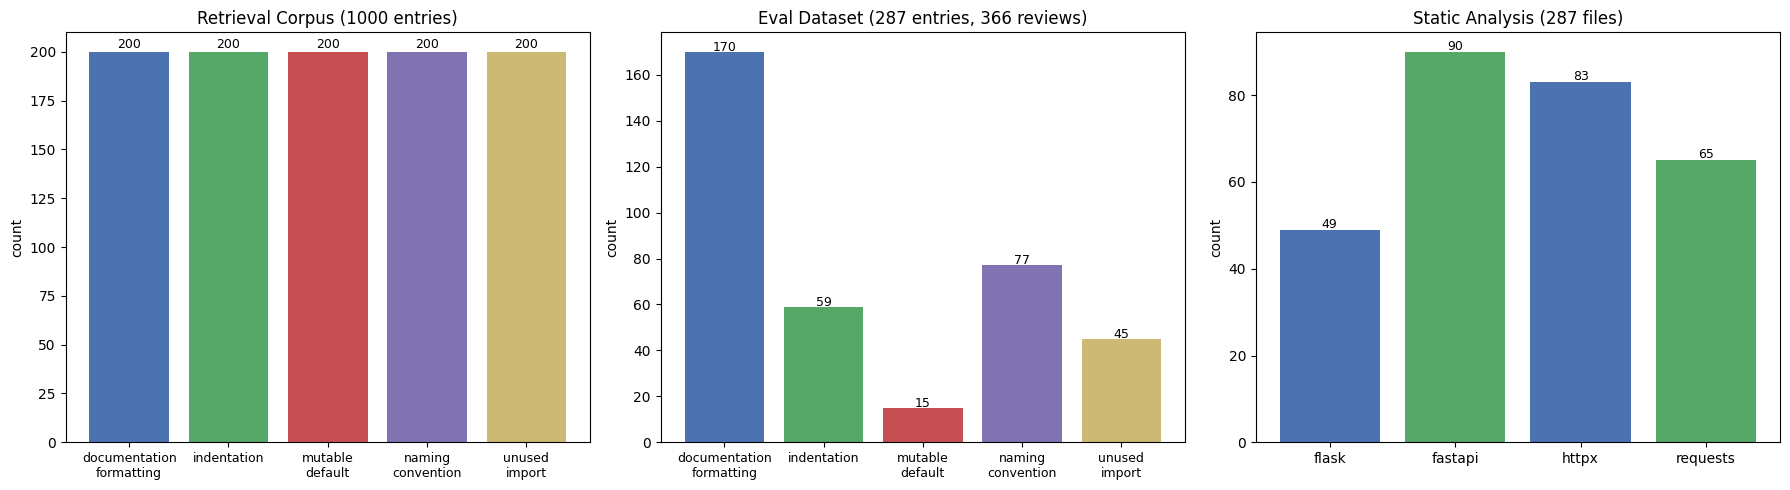

In [23]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['figure.dpi'] = 100

# category distribution across all 3 datasets
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. retrieval corpus by category
corpus_cats = Counter(c['category'] for c in corpus)
cats_sorted = sorted(corpus_cats.keys())
colors = ['#4C72B0', '#55A868', '#C44E52', '#8172B2', '#CCB974']

ax = axes[0]
bars = ax.bar(range(len(cats_sorted)), [corpus_cats[c] for c in cats_sorted], color=colors)
ax.set_xticks(range(len(cats_sorted)))
ax.set_xticklabels([c.replace('_', '\n') for c in cats_sorted], fontsize=9)
ax.set_title(f'Retrieval Corpus ({len(corpus)} entries)')
ax.set_ylabel('count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', fontsize=9)

# 2. eval dataset by category
eval_review_cats = Counter(r['violation_category'] for e in eval_dataset for r in e['ground_truth_reviews'])
ax = axes[1]
bars = ax.bar(range(len(cats_sorted)), [eval_review_cats.get(c, 0) for c in cats_sorted], color=colors)
ax.set_xticks(range(len(cats_sorted)))
ax.set_xticklabels([c.replace('_', '\n') for c in cats_sorted], fontsize=9)
ax.set_title(f'Eval Dataset ({len(eval_dataset)} entries, {sum(eval_review_cats.values())} reviews)')
ax.set_ylabel('count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontsize=9)

# 3. static analysis — files per eval repo
static_repos = Counter()
for e in eval_dataset:
    static_repos[e['repo'].split('/')[-1]] += 1
ax = axes[2]
bars = ax.bar(static_repos.keys(), static_repos.values(), color=['#4C72B0', '#55A868'])
ax.set_title(f'Static Analysis ({len(static_input)} files)')
ax.set_ylabel('count')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(int(bar.get_height())), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
### corpus source breakdown + comment length distribution

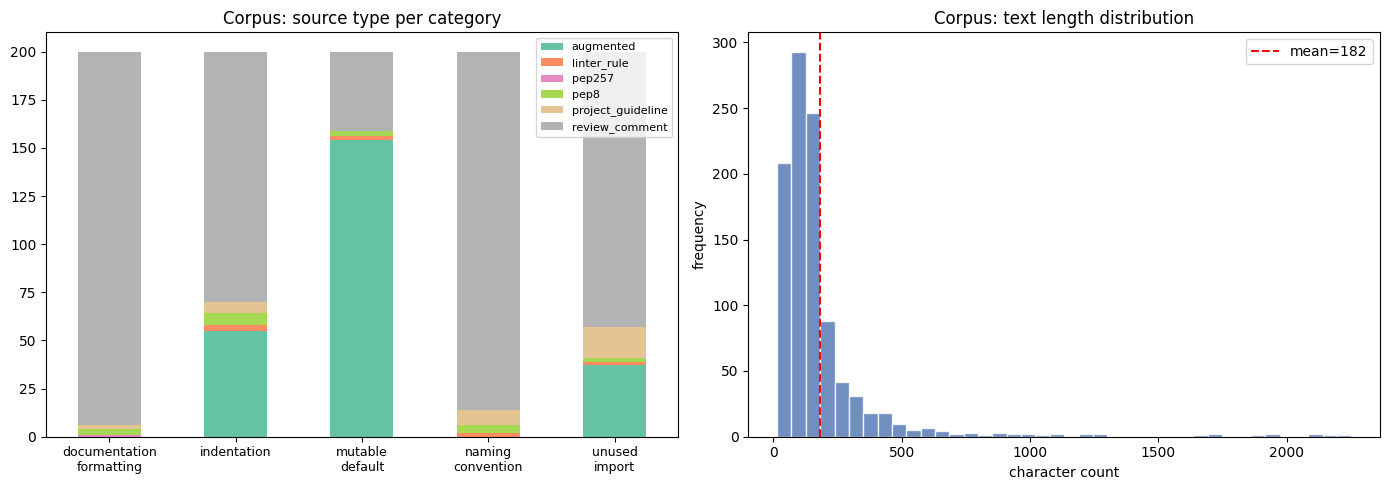

text length stats: min=15, max=2252, mean=182, median=126


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# source type breakdown (stacked bar per category)
df_c = pd.DataFrame(corpus)
pivot = df_c.groupby(['category', 'source_type']).size().unstack(fill_value=0)
pivot.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set2')
axes[0].set_title('Corpus: source type per category')
axes[0].set_xlabel('')
axes[0].set_xticklabels([t.get_text().replace('_', '\n') for t in axes[0].get_xticklabels()],
                         rotation=0, fontsize=9)
axes[0].legend(fontsize=8, loc='upper right')

# comment length distribution
lengths = [len(c['text']) for c in corpus]
axes[1].hist(lengths, bins=40, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[1].axvline(x=sum(lengths)/len(lengths), color='red', linestyle='--', label=f'mean={sum(lengths)//len(lengths)}')
axes[1].set_title('Corpus: text length distribution')
axes[1].set_xlabel('character count')
axes[1].set_ylabel('frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"text length stats: min={min(lengths)}, max={max(lengths)}, mean={sum(lengths)//len(lengths)}, median={sorted(lengths)[len(lengths)//2]}")

In [ ]:
### eval dataset — reviews per PR and diff chunk sizes

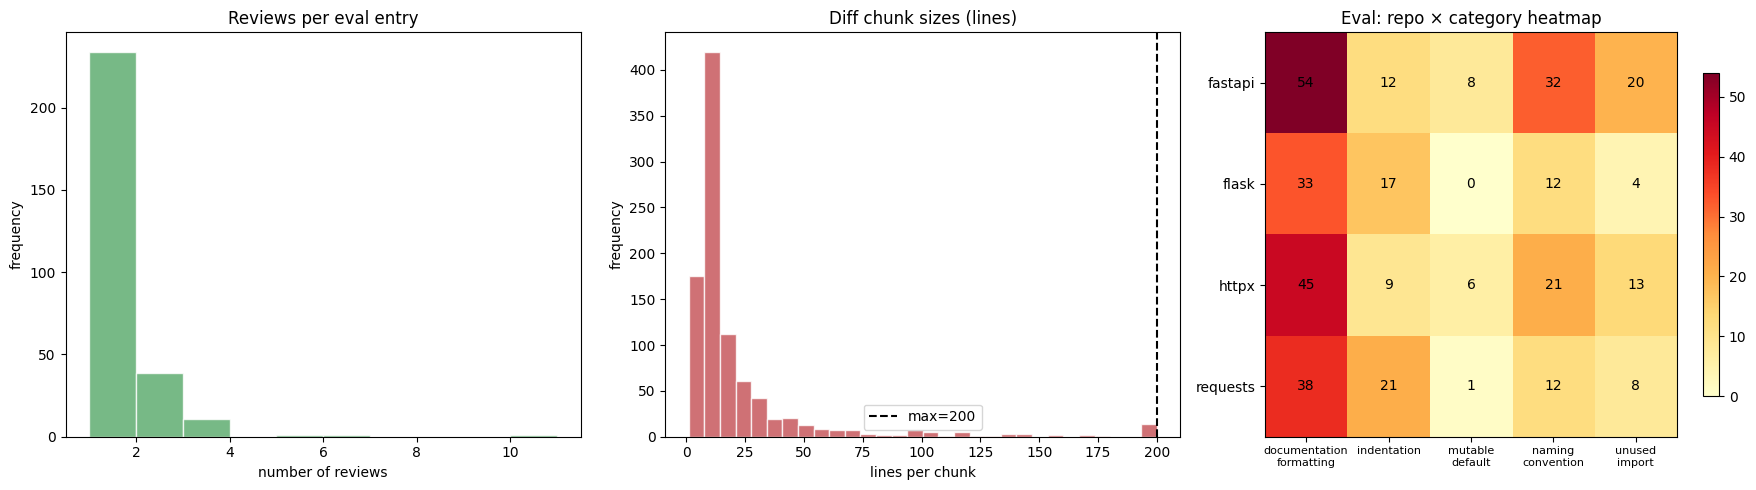

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# reviews per entry
reviews_per_entry = [len(e['ground_truth_reviews']) for e in eval_dataset]
axes[0].hist(reviews_per_entry, bins=range(1, max(reviews_per_entry) + 2),
             color='#55A868', edgecolor='white', alpha=0.8)
axes[0].set_title('Reviews per eval entry')
axes[0].set_xlabel('number of reviews')
axes[0].set_ylabel('frequency')

# diff chunk sizes
chunk_sizes = []
for e in eval_dataset:
    for chunk in e['diff_chunks']:
        chunk_sizes.append(len(chunk['diff_lines']))
if chunk_sizes:
    axes[1].hist(chunk_sizes, bins=30, color='#C44E52', edgecolor='white', alpha=0.8)
    axes[1].axvline(x=MAX_DIFF_LINES, color='black', linestyle='--', label=f'max={MAX_DIFF_LINES}')
    axes[1].set_title('Diff chunk sizes (lines)')
    axes[1].set_xlabel('lines per chunk')
    axes[1].set_ylabel('frequency')
    axes[1].legend()

# category heatmap — repo vs category
rows = []
for e in eval_dataset:
    repo_short = e['repo'].split('/')[-1]
    for r in e['ground_truth_reviews']:
        rows.append({'repo': repo_short, 'category': r['violation_category']})
if rows:
    df_heat = pd.DataFrame(rows)
    heat = df_heat.groupby(['repo', 'category']).size().unstack(fill_value=0)
    im = axes[2].imshow(heat.values, cmap='YlOrRd', aspect='auto')
    axes[2].set_xticks(range(heat.shape[1]))
    axes[2].set_xticklabels([c.replace('_', '\n') for c in heat.columns], fontsize=8)
    axes[2].set_yticks(range(heat.shape[0]))
    axes[2].set_yticklabels(heat.index)
    axes[2].set_title('Eval: repo × category heatmap')
    for i in range(heat.shape[0]):
        for j in range(heat.shape[1]):
            axes[2].text(j, i, str(heat.values[i, j]), ha='center', va='center', fontsize=10)
    plt.colorbar(im, ax=axes[2], shrink=0.8)

plt.tight_layout()
plt.show()

In [ ]:
### quick stats table

In [26]:
summary_rows = []
for cat in CATEGORIES:
    corpus_n = sum(1 for c in corpus if c['category'] == cat)
    eval_n = sum(1 for e in eval_dataset for r in e['ground_truth_reviews'] if r['violation_category'] == cat)
    summary_rows.append({
        'category': cat,
        'corpus': corpus_n,
        'eval_reviews': eval_n,
        'corpus_%': f"{corpus_n/len(corpus)*100:.1f}%",
        'eval_%': f"{eval_n/sum(len(e['ground_truth_reviews']) for e in eval_dataset)*100:.1f}%" if eval_dataset else '0%',
    })

df_summary = pd.DataFrame(summary_rows)
df_summary.loc[len(df_summary)] = {
    'category': 'TOTAL',
    'corpus': len(corpus),
    'eval_reviews': sum(len(e['ground_truth_reviews']) for e in eval_dataset),
    'corpus_%': '100%',
    'eval_%': '100%',
}

print(df_summary.to_string(index=False))

for fname in ['retrieval_corpus.json', 'evaluation_dataset.json', 'static_analysis_input.json']:
    p = Path(fname)
    if p.exists():
        mb = p.stat().st_size / (1024 * 1024)
        print(f"\n{fname}: {mb:.2f} MB")

                category  corpus  eval_reviews corpus_% eval_%
             indentation     200            59    20.0%  16.1%
       naming_convention     200            77    20.0%  21.0%
           unused_import     200            45    20.0%  12.3%
         mutable_default     200            15    20.0%   4.1%
documentation_formatting     200           170    20.0%  46.4%
                   TOTAL    1000           366     100%   100%

retrieval_corpus.json: 0.29 MB

evaluation_dataset.json: 1.24 MB

static_analysis_input.json: 6.70 MB
